In [1]:
import numpy as np 
import xarray as xr
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from glob import glob
import matplotlib as mpl       

In [2]:
%run funs.ipynb

In [3]:
basecase_vals = xr.open_dataset('/fmi/scratch/project_2001927/chandras/TM5/TM5/risto_figure_plots/basecase_pathvals_surface.nc')
so4nucl_vals = xr.open_dataset('/fmi/scratch/project_2001927/chandras/TM5/TM5/risto_figure_plots/so4nucl_pathvals_surface.nc')
bulkmsa_vals = xr.open_dataset('/fmi/scratch/project_2001927/chandras/TM5/TM5/risto_figure_plots/bulkmsa_pathvals_surface.nc')
dmshigh_vals = xr.open_dataset('/fmi/scratch/project_2001927/chandras/TM5/TM5/risto_figure_plots/dmshigh_pathvals_surface.nc')
dmslow_vals = xr.open_dataset('/fmi/scratch/project_2001927/chandras/TM5/TM5/risto_figure_plots/dmslow_pathvals_surface.nc')
msaelvoc_vals = xr.open_dataset('/fmi/scratch/project_2001927/chandras/TM5/TM5/risto_figure_plots/msaelvoc_pathvals_surface.nc')
msasvoc_vals =  xr.open_dataset('/fmi/scratch/project_2001927/chandras/TM5/TM5/risto_figure_plots/msasvoc_pathvals_surface.nc')
nuclhigh_vals  = xr.open_dataset('/fmi/scratch/project_2001927/chandras/TM5/TM5/risto_figure_plots/nuclhigh_pathvals_surface.nc')
nucllow_vals = xr.open_dataset('/fmi/scratch/project_2001927/chandras/TM5/TM5/risto_figure_plots/nucllow_pathvals_surface.nc')
sshigh_vals = xr.open_dataset('/fmi/scratch/project_2001927/chandras/TM5/TM5/risto_figure_plots/sshigh_pathvals_surface.nc')
sslow_vals = xr.open_dataset('/fmi/scratch/project_2001927/chandras/TM5/TM5/risto_figure_plots/sslow_pathvals_surface.nc')



In [4]:
# calculates the houly average location of Polarstern
latitude,longitude = lat_lon('cpc3025_corrected_10s.tab',39,'Latitude','Longitude')

mosaic_vals = read_files('cpc3025_pollution_flag_1min(1).tab',43,'Flag','CP_conc [#/cm**3]')
mosaic_vals = mosaic_vals.reset_index()
#mosaic_mon_vals = monthly_file('cpc3025_pollution_flag_1min(1).tab',43,'Flag','CP_conc [#/cm**3]')

                      Latitude   Longitude  CP_conc [#/cm**3]  Flag
Date/Time                                                          
2019-10-01 00:00:00  85.060945  136.955266          15.297350   0.0
2019-10-01 01:00:00  85.060477  136.936431          21.753800   0.0
2019-10-01 02:00:00  85.059641  136.922660          27.696417   0.0
2019-10-01 03:00:00  85.058192  136.911913          22.725783   0.0
2019-10-01 04:00:00  85.056233  136.901118          27.561067   0.0
...                        ...         ...                ...   ...
2020-09-30 19:00:00        NaN         NaN                NaN   NaN
2020-09-30 20:00:00        NaN         NaN                NaN   NaN
2020-09-30 21:00:00        NaN         NaN                NaN   NaN
2020-09-30 22:00:00  80.964737    4.160653          16.646200   0.0
2020-09-30 23:00:00  80.960670    4.159633          27.604610   0.0

[8784 rows x 4 columns]


In [5]:
colors = ['#EE7733','#0077BB','#33BBEE','#EE3377','#CC3311','#009988']

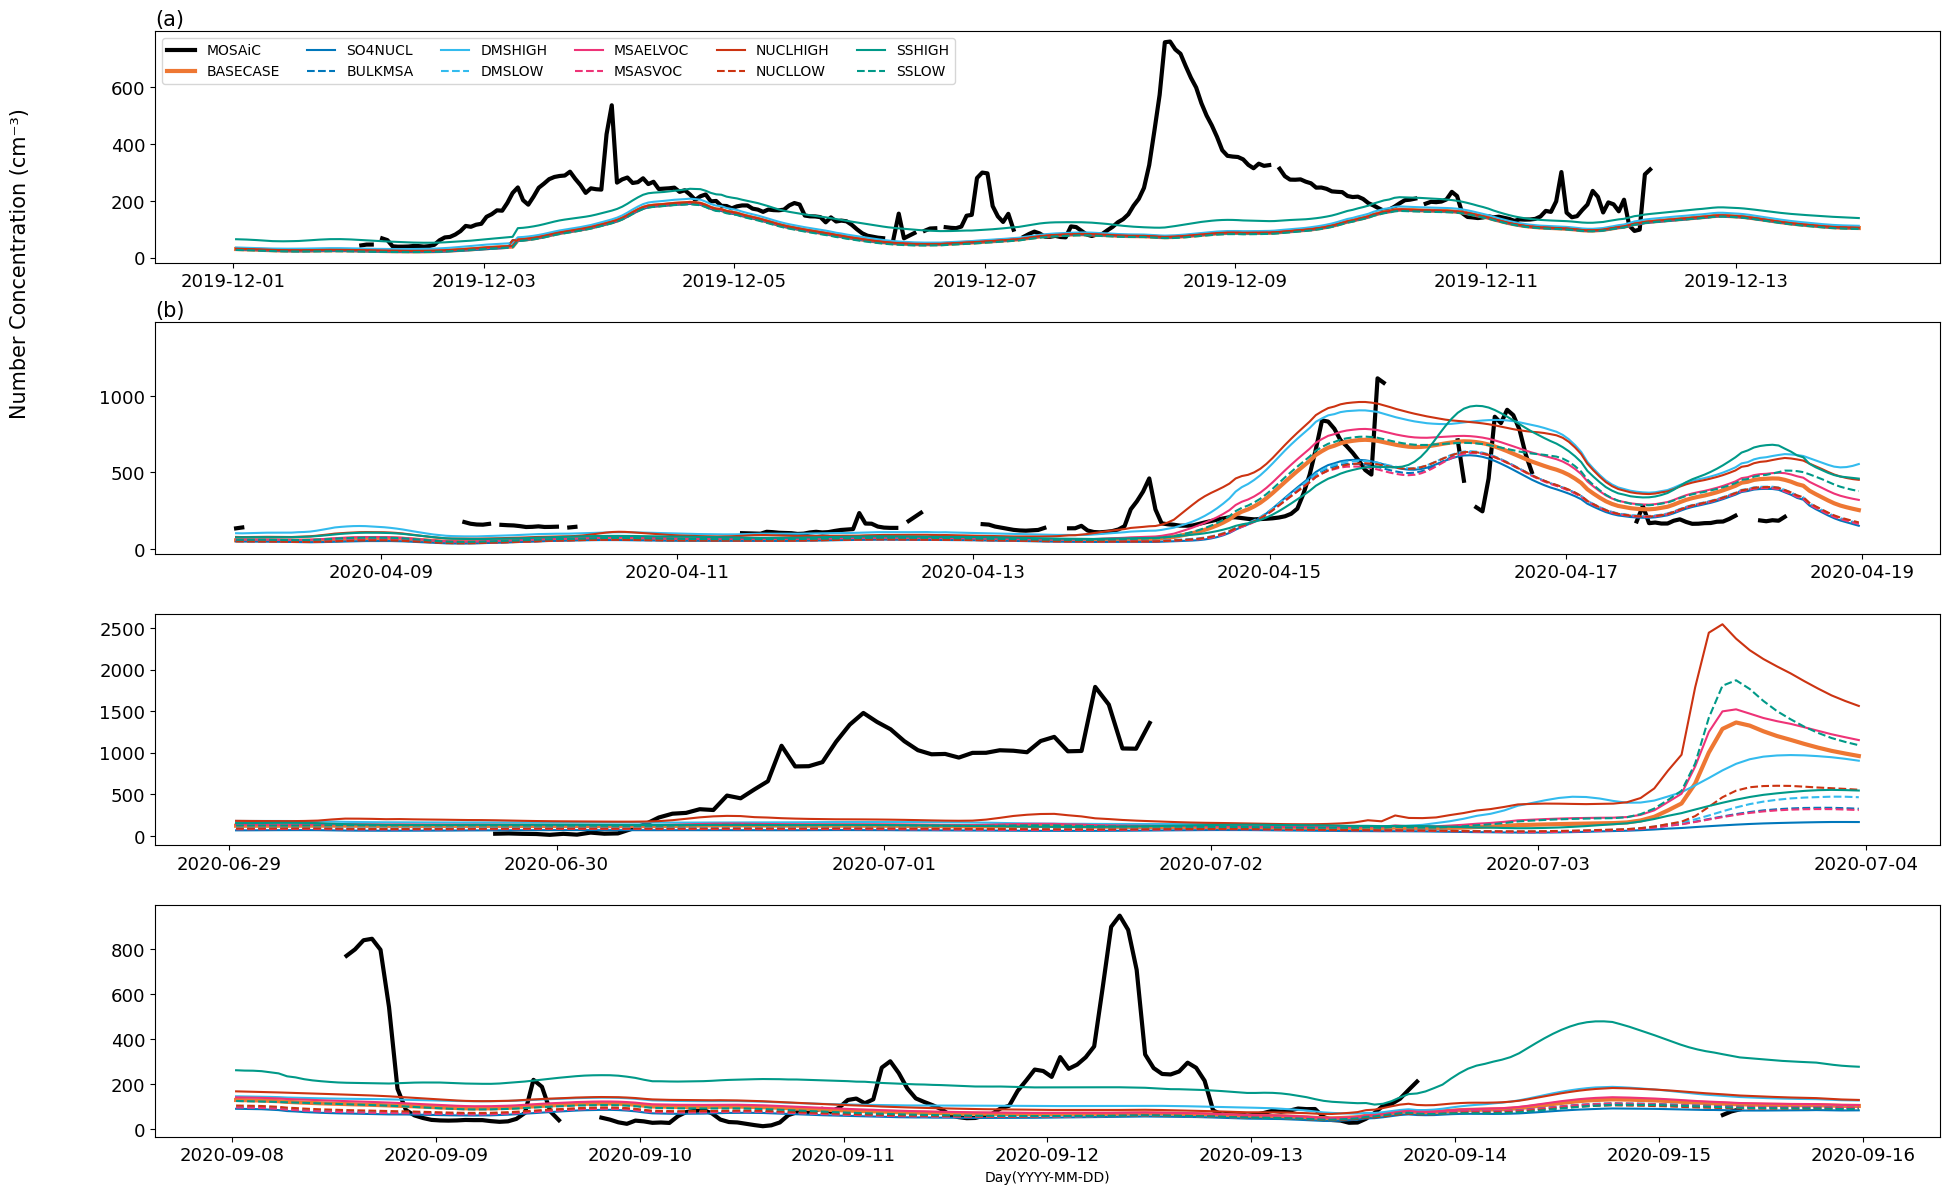

In [6]:
fig,ax = plt.subplots(4,figsize = (20,12))
indices = ['(a)','(b)','(c)','(d)']
for i in range(2):
    ax[i].text(0, 1.025,indices[i],transform=ax[i].transAxes,size = 15)
# selecting the dates for the event in MM-DD-YYYY format. xarray and pandas seem to have different methods for setting the end dates. the event_end2 is for xarray, which takes all points during that day whereas pandas takes all values before the given day
event_start = '04-08-2020'
event_end = '04-19-2020'
event_end2 = '04-18-2020'

# creating a time slice for the period we need
mosaic_event = mosaic_vals[(mosaic_vals['Date/Time'] >= pd.to_datetime(event_start)) & (mosaic_vals['Date/Time'] < pd.to_datetime(event_end))]
basecase_event = basecase_vals.sel(time=slice(event_start, event_end2))
so4nucl_event = so4nucl_vals.sel(time=slice(event_start, event_end2))
bulkmsa_event = bulkmsa_vals.sel(time=slice(event_start, event_end2))
dmslow_event = dmslow_vals.sel(time=slice(event_start, event_end2))
dmshigh_event = dmshigh_vals.sel(time=slice(event_start, event_end2))
msaelvoc_event = msaelvoc_vals.sel(time=slice(event_start, event_end2))
msasvoc_event =  msasvoc_vals.sel(time=slice(event_start, event_end2))
nuclhigh_event =nuclhigh_vals.sel(time=slice(event_start, event_end2))
nucllow_event = nucllow_vals.sel(time=slice(event_start, event_end2))
sshigh_event = sshigh_vals.sel(time=slice(event_start, event_end2))
sslow_event = sslow_vals.sel(time=slice(event_start, event_end2))

ax[1].plot(basecase_event.time, mosaic_event['CP_conc [#/cm**3]'],label = 'MOSAiC',color = 'k',linewidth = 3)
ax[1].plot(basecase_event.time, basecase_event.conccn,label = 'BASECASE',color = colors[0],linewidth = 3)
ax[1].plot(basecase_event.time, so4nucl_event.conccn, label = 'SO4NUCL',color = colors[1])
ax[1].plot(basecase_event.time, bulkmsa_event.conccn, label = 'BULKMSA', color = colors[1],linestyle = '--')
ax[1].plot(basecase_event.time, dmshigh_event.conccn,label = 'DMSHIGH',color = colors[2])
ax[1].plot(basecase_event.time, dmslow_event.conccn,label = 'DMSLOW',color = colors[2],linestyle = '--')
ax[1].plot(basecase_event.time, msaelvoc_event.conccn,label = 'MSAELVOC',color = colors[3])
ax[1].plot(basecase_event.time, msasvoc_event.conccn,label = 'MSASVOC',color = colors[3],linestyle = '--')
ax[1].plot(basecase_event.time, nuclhigh_event.conccn,label = 'NUCLHIGH',color = colors[4])
ax[1].plot(basecase_event.time, nucllow_event.conccn, label = 'NUCLLOW',color = colors[4],linestyle = '--')
ax[1].plot(basecase_event.time, sshigh_event.conccn,label = 'SSHIGH',color = colors[5])
ax[1].plot(basecase_event.time, sslow_event.conccn, label = 'SSLOW',color = colors[5],linestyle = '--')
#plt.yscale('log')
#ax[1].set_xlabel('Day(YYYY-MM-DD)')
#ax[1].set_ylabel('Number Concentration (cm⁻³)')


event_start = '12-01-2019'
event_end = '12-14-2019'
event_end2 = '12-13-2019'
mosaic_event = mosaic_vals[(mosaic_vals['Date/Time'] >= pd.to_datetime(event_start)) & (mosaic_vals['Date/Time'] < pd.to_datetime(event_end))]
basecase_event = basecase_vals.sel(time=slice(event_start, event_end2))
so4nucl_event = so4nucl_vals.sel(time=slice(event_start, event_end2))
bulkmsa_event = bulkmsa_vals.sel(time=slice(event_start, event_end2))
dmslow_event = dmslow_vals.sel(time=slice(event_start, event_end2))
dmshigh_event = dmshigh_vals.sel(time=slice(event_start, event_end2))
msaelvoc_event = msaelvoc_vals.sel(time=slice(event_start, event_end2))
msasvoc_event =  msasvoc_vals.sel(time=slice(event_start, event_end2))
nuclhigh_event =nuclhigh_vals.sel(time=slice(event_start, event_end2))
nucllow_event = nucllow_vals.sel(time=slice(event_start, event_end2))
sshigh_event = sshigh_vals.sel(time=slice(event_start, event_end2))
sslow_event = sslow_vals.sel(time=slice(event_start, event_end2))


ax[0].plot(basecase_event.time, mosaic_event['CP_conc [#/cm**3]'],label = 'MOSAiC',color = 'k',linewidth = 3)
ax[0].plot(basecase_event.time, basecase_event.conccn,label = 'BASECASE',color = colors[0],linewidth = 3)
ax[0].plot(basecase_event.time, so4nucl_event.conccn, label = 'SO4NUCL',color = colors[1])
ax[0].plot(basecase_event.time, bulkmsa_event.conccn, label = 'BULKMSA', color = colors[1],linestyle = '--')
ax[0].plot(basecase_event.time, dmshigh_event.conccn,label = 'DMSHIGH',color = colors[2])
ax[0].plot(basecase_event.time, dmslow_event.conccn,label = 'DMSLOW',color = colors[2],linestyle = '--')
ax[0].plot(basecase_event.time, msaelvoc_event.conccn,label = 'MSAELVOC',color = colors[3])
ax[0].plot(basecase_event.time, msasvoc_event.conccn,label = 'MSASVOC',color = colors[3],linestyle = '--')
ax[0].plot(basecase_event.time, nuclhigh_event.conccn,label = 'NUCLHIGH',color = colors[4])
ax[0].plot(basecase_event.time, nucllow_event.conccn, label = 'NUCLLOW',color = colors[4],linestyle = '--')
ax[0].plot(basecase_event.time, sshigh_event.conccn,label = 'SSHIGH',color = colors[5])
ax[0].plot(basecase_event.time, sslow_event.conccn, label = 'SSLOW',color = colors[5],linestyle = '--')
#ax[0].set_xlabel('Day(YYYY-MM-DD)')
#ax[0].set_ylabel('Number Concentration(cm⁻³)')
#ax[0]yscale('log')
ax[0].legend(ncols = 6)


event_start = '06-29-2020'
event_end = '07-04-2020'
event_end2 = '07-03-2020'
mosaic_event = mosaic_vals[(mosaic_vals['Date/Time'] >= pd.to_datetime(event_start)) & (mosaic_vals['Date/Time'] < pd.to_datetime(event_end))]
basecase_event = basecase_vals.sel(time=slice(event_start, event_end2))
so4nucl_event = so4nucl_vals.sel(time=slice(event_start, event_end2))
bulkmsa_event = bulkmsa_vals.sel(time=slice(event_start, event_end2))
dmslow_event = dmslow_vals.sel(time=slice(event_start, event_end2))
dmshigh_event = dmshigh_vals.sel(time=slice(event_start, event_end2))
msaelvoc_event = msaelvoc_vals.sel(time=slice(event_start, event_end2))
msasvoc_event =  msasvoc_vals.sel(time=slice(event_start, event_end2))
nuclhigh_event =nuclhigh_vals.sel(time=slice(event_start, event_end2))
nucllow_event = nucllow_vals.sel(time=slice(event_start, event_end2))
sshigh_event = sshigh_vals.sel(time=slice(event_start, event_end2))
sslow_event = sslow_vals.sel(time=slice(event_start, event_end2))


ax[2].plot(basecase_event.time, mosaic_event['CP_conc [#/cm**3]'],label = 'MOSAiC',color = 'k',linewidth = 3)
ax[2].plot(basecase_event.time, basecase_event.conccn,label = 'BASECASE',color = colors[0],linewidth = 3)
ax[2].plot(basecase_event.time, so4nucl_event.conccn, label = 'SO4NUCL',color = colors[1])
ax[2].plot(basecase_event.time, bulkmsa_event.conccn, label = 'BULKMSA', color = colors[1],linestyle = '--')
ax[2].plot(basecase_event.time, dmshigh_event.conccn,label = 'DMSHIGH',color = colors[2])
ax[2].plot(basecase_event.time, dmslow_event.conccn,label = 'DMSLOW',color = colors[2],linestyle = '--')
ax[2].plot(basecase_event.time, msaelvoc_event.conccn,label = 'MSAELVOC',color = colors[3])
ax[2].plot(basecase_event.time, msasvoc_event.conccn,label = 'MSASVOC',color = colors[3],linestyle = '--')
ax[2].plot(basecase_event.time, nuclhigh_event.conccn,label = 'NUCLHIGH',color = colors[4])
ax[2].plot(basecase_event.time, nucllow_event.conccn, label = 'NUCLLOW',color = colors[4],linestyle = '--')
ax[2].plot(basecase_event.time, sshigh_event.conccn,label = 'SSHIGH',color = colors[5])
ax[2].plot(basecase_event.time, sslow_event.conccn, label = 'SSLOW',color = colors[5],linestyle = '--')
#plt.fill_between(basecase_event.time,0, basecase_rolling.conccn, color='b', alpha=0.1)
#ax[2].set_xlabel('Day(YYYY-MM-DD)')
#ax[2].set_ylabel('Aerosol Number Concentration(#/cm³)')



event_start = '09-08-2020'
event_end = '09-16-2020'
event_end2 = '09-15-2020'
mosaic_event = mosaic_vals[(mosaic_vals['Date/Time'] >= pd.to_datetime(event_start)) & (mosaic_vals['Date/Time'] < pd.to_datetime(event_end))]
basecase_event = basecase_vals.sel(time=slice(event_start, event_end2))
so4nucl_event = so4nucl_vals.sel(time=slice(event_start, event_end2))
bulkmsa_event = bulkmsa_vals.sel(time=slice(event_start, event_end2))
dmslow_event = dmslow_vals.sel(time=slice(event_start, event_end2))
dmshigh_event = dmshigh_vals.sel(time=slice(event_start, event_end2))
msaelvoc_event = msaelvoc_vals.sel(time=slice(event_start, event_end2))
msasvoc_event =  msasvoc_vals.sel(time=slice(event_start, event_end2))
nuclhigh_event =nuclhigh_vals.sel(time=slice(event_start, event_end2))
nucllow_event = nucllow_vals.sel(time=slice(event_start, event_end2))
sshigh_event = sshigh_vals.sel(time=slice(event_start, event_end2))
sslow_event = sslow_vals.sel(time=slice(event_start, event_end2))


ax[3].plot(basecase_event.time, mosaic_event['CP_conc [#/cm**3]'],label = 'MOSAiC',color = 'k',linewidth = 3)
ax[3].plot(basecase_event.time, basecase_event.conccn,label = 'BASECASE',color = colors[0],linewidth = 3)
ax[3].plot(basecase_event.time, so4nucl_event.conccn, label = 'SO4NUCL',color = colors[1])
ax[3].plot(basecase_event.time, bulkmsa_event.conccn, label = 'BULKMSA', color = colors[1],linestyle = '--')
ax[3].plot(basecase_event.time, dmshigh_event.conccn,label = 'DMSHIGH',color = colors[2])
ax[3].plot(basecase_event.time, dmslow_event.conccn,label = 'DMSLOW',color = colors[2],linestyle = '--')
ax[3].plot(basecase_event.time, msaelvoc_event.conccn,label = 'MSAELVOC',color = colors[3])
ax[3].plot(basecase_event.time, msasvoc_event.conccn,label = 'MSASVOC',color = colors[3],linestyle = '--')
ax[3].plot(basecase_event.time, nuclhigh_event.conccn,label = 'NUCLHIGH',color = colors[4])
ax[3].plot(basecase_event.time, nucllow_event.conccn, label = 'NUCLLOW',color = colors[4],linestyle = '--')
ax[3].plot(basecase_event.time, sshigh_event.conccn,label = 'SSHIGH',color = colors[5])
ax[3].plot(basecase_event.time, sslow_event.conccn, label = 'SSLOW',color = colors[5],linestyle = '--')

#plt.fill_between(basecase_event.time,0, basecase_rolling.conccn, color='b', alpha=0.1)
ax[3].set_xlabel('Day(YYYY-MM-DD)')
plt.tight_layout()
fig.subplots_adjust(left=0.1)
fig.text(-0.07, 0, 'Number Concentration (cm⁻³)', va='bottom', ha='center',rotation='vertical', rotation_mode='anchor',transform=ax[0].transAxes,fontsize = 15)
#ax[3].set_ylabel('Aerosol Number Concentration(#/cm³)')
#plt.yscale('log')
for i in range(4):
    ax[i].tick_params(labelsize=13)


plt.savefig('aerosol_events.jpg',dpi = 300)